# Gemini API: Automated Invoice and Form Data Extraction with Gemini API & Zod

This notebook demonstrates how you can convert a PDF file so that it can be read by the Gemini API.


## Setup

### Install the Google GenAI SDK

Install the Google GenAI SDK from [npm](https://www.npmjs.com/package/@google/genai). 

```bash
$ npm install @google/genai
```

### Setup your API key

You can [create](https://aistudio.google.com/app/apikey) your API key using Google AI Studio with a single click.

Remember to treat your API key like a password. Don't accidentally save it in a notebook or source file you later commit to GitHub. In this notebook we will be storing the API key in a `.env` file. You can also set it as an environment variable or use a secret manager. 

Here's how to set it up in a `.env` file:

```bash
$ touch .env
$ echo "GEMINI_API_KEY=<YOUR_API_KEY>" >> .env
```

:::{.callout-tip}

Another option is to set the API key as an environment variable. You can do this in your terminal with the following command:

```bash
$ export GEMINI_API_KEY="<YOUR_API_KEY>"
```
:::

### Load the API key

To load the API key from the `.env` file, we will use the `dotenv` package. This package loads environment variables from a `.env` file into `process.env`. 

```bash
$ npm install dotenv
```

Then, we can load the API key in our code:


In [1]:
const dotenv = require("dotenv") as typeof import("dotenv");

dotenv.config({
  path: "../.env",
});

const GEMINI_API_KEY = process.env.GEMINI_API_KEY ?? "";
if (!GEMINI_API_KEY) {
  throw new Error("GEMINI_API_KEY is not set in the environment variables");
}
console.log("GEMINI_API_KEY is set in the environment variables");


GEMINI_API_KEY is set in the environment variables


:::{.callout-note}
In our particular case the `.env` is is one directory up from the notebook, hence we need to use `../` to go up one directory. If the `.env` file is in the same directory as the notebook, you can omit it altogether. 

```
│
├── .env
└── examples
    └── Pdf_structured_outputs_on_invoices_and_forms.ipynb
```
:::


### Initialize SDK Client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.


In [2]:
const google = require("@google/genai") as typeof import("@google/genai");

const ai = new google.GoogleGenAI({ apiKey: GEMINI_API_KEY });


### Select a model

Now select the model you want to use in this guide, either by selecting one in the list or writing it down. Keep in mind that some models, like the 2.5 ones are thinking models and thus take slightly more time to respond (cf. [thinking notebook](../quickstarts/Get_started_thinking.ipynb) for more details and in particular learn how to switch the thiking off).


In [3]:
const tslab = require("tslab") as typeof import("tslab");

const MODEL_ID = "gemini-2.5-flash-preview-05-20";


## Work with PDFs and other files

Gemini models are able to process [images and videos](https://ai.google.dev/gemini-api/docs/vision?lang=javascript#image-input), which can used with base64 strings or using the `files` api. After uploading the file you can include the file uri in the call directly. 

For this example you have 2 PDFs samples, one basic invoice and on form with and written values.


In [4]:
const fs = require("fs") as typeof import("fs");
const path = require("path") as typeof import("path");

const downloadFile = async (url: string, filePath: string) => {
  const response = await fetch(url);
  if (!response.ok) {
    throw new Error(`Failed to download file: ${response.statusText}`);
  }
  fs.mkdirSync(path.dirname(filePath), { recursive: true });
  const buffer = await response.blob();
  const bufferData = Buffer.from(await buffer.arrayBuffer());
  fs.writeFileSync(filePath, bufferData);
};


In [5]:
const FORM_PDF_URL =
  "https://storage.googleapis.com/generativeai-downloads/data/pdf_structured_outputs/handwriting_form.pdf";
const INVOICE_PDF_URL = "https://storage.googleapis.com/generativeai-downloads/data/pdf_structured_outputs/invoice.pdf";

const formPdfPath = path.join("../assets/pdf_structured_outputs", "handwriting_form.pdf");
const invoicePdfPath = path.join("../assets/pdf_structured_outputs", "invoice.pdf");

await downloadFile(FORM_PDF_URL, formPdfPath);
await downloadFile(INVOICE_PDF_URL, invoicePdfPath);


You can now upload the files using our client with the `upload` method. Let's try this for one of the files.


In [6]:
const invoiceFile = await ai.files.upload({
  file: invoicePdfPath,
  config: {
    mimeType: "application/pdf",
    displayName: "Invoice PDF",
  },
});


:::{.callout-note}

The File API lets you store up to 20 GB of files per project, with a per-file maximum size of 2 GB. Files are stored for 48 hours. They can be accessed in that period with your API key, but they cannot be downloaded. File uploads are available at no cost.

:::

After a file is uploaded you can check to how many tokens it got converted. This not only help us understand the context you are working with it also helps to keep track of the cost.


In [7]:
const invoiceFileSize = await ai.models.countTokens({
  model: MODEL_ID,
  contents: [google.createPartFromUri(invoiceFile.uri ?? "", invoiceFile.mimeType ?? "application/pdf")],
});
console.log(`File: ${invoiceFile.displayName} equals to ${invoiceFileSize.totalTokens} tokens.`);


File: Invoice PDF equals to 259 tokens.


## Structured outputs with Gemini 2.x & Zod

Structured Outputs is a feature that ensures Gemini always generate responses that adhere to a predefined format, such as JSON Schema. This means you have more control over the output and how to integrate it into our application as it is guaranteed to return a valid JSON object with the schema you define.

Gemini 2.x currently supports 3 different types of how to define a JSON schemas:

- A primitive type following [OpenAPI 3.0 schema object](https://spec.openapis.org/oas/v3.0.3#schema), such as `string`, `number`, `boolean`, `object`, `array`, etc.
- A [zod](https://zod.dev/) object
- An object following the sdk [`types.Schema`](https://googleapis.github.io/js-genai/release_docs/interfaces/types.Schema.html) interface.
  
Lets look at quick text-based example.


In [8]:
import * as z from "zod";
import { zodToJsonSchema } from "zod-to-json-schema";

const topicSchema = z.object({
  name: z.string().describe("The name of the topic"),
});

const personSchema = z.object({
  firstName: z.string().describe("The first name of the person"),
  lastName: z.string().describe("The last name of the person"),
  age: z.number().int().describe("The age of the person, if not provided please return 0").default(0),
  workTopics: z
    .array(topicSchema)
    .describe("The fields of interest of the person, if not provided please return an empty array")
    .default([]),
});

const personResponse = await ai.models.generateContent({
  model: MODEL_ID,
  contents:
    "Philipp Schmid is a Senior AI Developer Relations Engineer at Google DeepMind working on Gemini, Gemma with the mission to help every developer to build and benefit from AI in a responsible way.",
  config: {
    responseJsonSchema: zodToJsonSchema(personSchema),
    responseMimeType: "application/json",
  },
});
const person = JSON.parse(personResponse.text ?? "{}") as z.infer<typeof personSchema>;
console.log(JSON.stringify(person, null, 2));


{
  "firstName": "Philipp",
  "lastName": "Schmid",
  "age": 0,
  "workTopics": [
    {
      "name": "Gemini"
    },
    {
      "name": "Gemma"
    },
    {
      "name": "AI"
    }
  ]
}


## Extract Structured data from PDFs using Gemini 2.x

Now, let's combine the File API and structured output to extract information from our PDFs. You can create a simple method that accepts a local file path and a zod schema and return the structured data for us. The method will:

- Upload the file to the File API
- Generate a structured response using the Gemini API
- Convert the response to the zod schema and return it


In [9]:
import { File, FileState, UploadFileConfig } from "@google/genai";

async function deferredFileUpload(filePath: string, config: UploadFileConfig): Promise<File> {
  const file = await ai.files.upload({
    file: filePath,
    config,
  });
  let getFile = await ai.files.get({ name: file.name ?? "" });
  while (getFile.state === FileState.PROCESSING) {
    getFile = await ai.files.get({ name: file.name ?? "" });
    console.log(`current file status (${getFile.displayName}): ${getFile.state ?? "unknown"}`);
    console.log("File is still processing, retrying in 5 seconds");

    await new Promise((resolve) => {
      setTimeout(resolve, 5000);
    });
  }
  if (file.state === FileState.FAILED) {
    throw new Error("File processing failed.");
  }
  console.log(`File ${file.displayName} is ready. [${file.state}]`);
  return file;
}


In [ ]:
async function extractStructuredDataFromPdf<T extends z.ZodTypeAny>(filePath: string, schema: T): Promise<z.infer<T>> {
  const file = await deferredFileUpload(filePath, { displayName: filePath.split("/").pop()?.split(".")[0] });
  const response = await ai.models.generateContent({
    model: MODEL_ID,
    contents: [
      "Extract the structured data from the following PDF file",
      google.createPartFromUri(file.uri ?? "", file.mimeType ?? ""),
    ],
    config: {
      responseJsonSchema: zodToJsonSchema(schema),
      responseMimeType: "application/json",
    },
  });
  const structuredData = JSON.parse(response.text ?? "{}") as z.infer<T>;
  if (!schema.safeParse(structuredData).success) {
    throw new Error("Structured data does not match the schema");
  }
  // eslint-disable-next-line @typescript-eslint/no-unsafe-return
  return structuredData;
}


In our Example every PDF is a different to each other. So you want to define unique zod schemas for each PDF to show the performance of the Gemini 2.x. If you have very similar PDFs and want to extract the same information you can use the same model for all of them.

- `Invoice.pdf` : Extract the invoice number, date and all list items with description, quantity and gross worth and the total gross worth
- `handwriting_form.pdf` : Extract the form number, plan start date and the plan liabilities beginning of the year and end of the year

:::{.callout-note}

Using zod features you can add more context to the model to make it more accurate as well as some validation to the data. Adding a comprehensive description can significantly improve the performance of the model. 

:::


### Invoice.pdf

Let's first take a look at the invoice PDF. The invoice contains the following information:


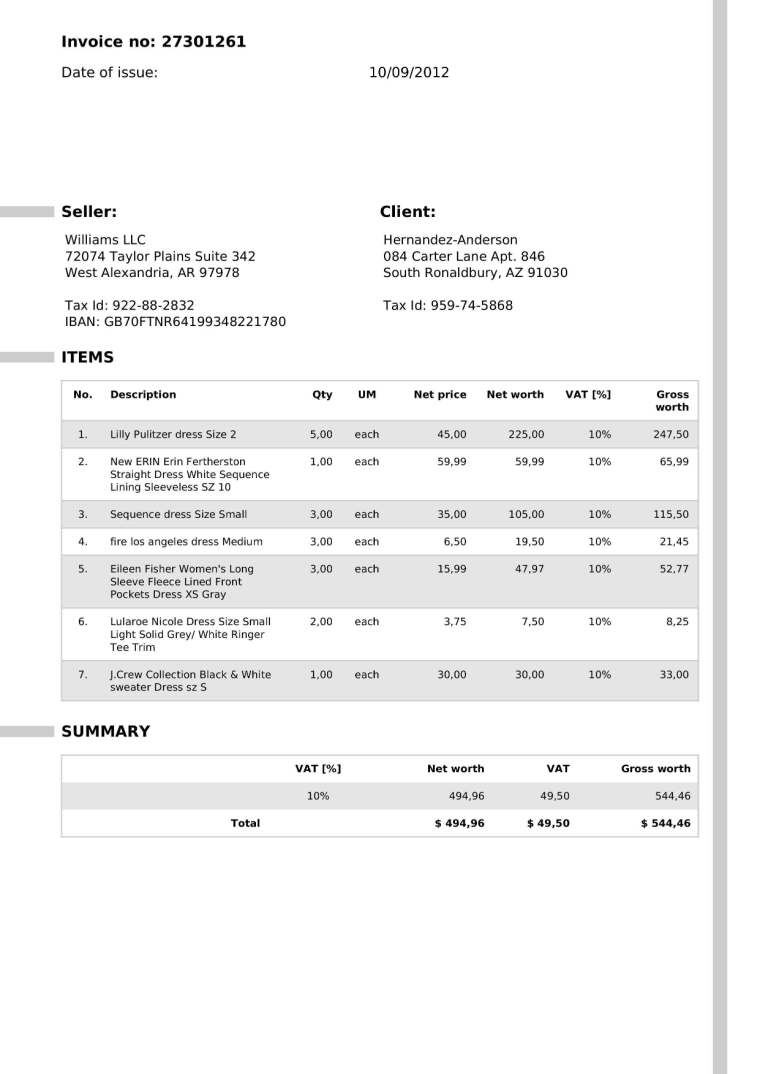

In [11]:
const getPage = async (pdfPath: string, pageNumber: number): Promise<Uint8Array> => {
  const { pdf } = await import("pdf-to-img");
  const document = await pdf(pdfPath);
  let pageIndex = 0;
  for await (const page of document) {
    if (pageIndex === pageNumber) {
      return new Uint8Array(page);
    }
    pageIndex++;
  }
  throw new Error(`Page ${pageNumber} not found in the PDF document.`);
};

tslab.display.png(await getPage(invoicePdfPath, 0));


In [14]:
const itemSchema = z
  .object({
    description: z.string().describe("The description of the item"),
    quantity: z.number().int().describe("The quantity of the item"),
    grossWorth: z.number().describe("The gross worth of the item"),
  })
  .describe("The item in the invoice");

const invoiceSchema = z
  .object({
    invoiceNumber: z.string().describe("The invoice number e.g. 1234567890"),
    date: z.string().describe("The date of the invoice e.g. 2024-01-01"),
    items: z.array(itemSchema).describe("The list of items with description, quantity and gross worth"),
    totalGrossWorth: z.number().describe("The total gross worth of the invoice"),
  })
  .describe("The invoice data extracted from the PDF");

const invoiceData = await extractStructuredDataFromPdf<typeof invoiceSchema>(invoicePdfPath, invoiceSchema);
console.log(
  `Extracted Invoice: ${invoiceData.invoiceNumber} on ${invoiceData.date} with total gross worth ${invoiceData.totalGrossWorth}`
);
for (const item of invoiceData.items) {
  console.log(`Item: ${item.description} with quantity ${item.quantity} and gross worth ${item.grossWorth}`);
}


File invoice is ready. [ACTIVE]
Extracted Invoice: 27301261 on 2012-09-10 with total gross worth 544.46
Item: Lilly Pulitzer dress Size 2 with quantity 5 and gross worth 247.5
Item: New ERIN Erin Fertherston Straight Dress White Sequence Lining Sleeveless SZ 10 with quantity 1 and gross worth 65.99
Item: Sequence dress Size Small with quantity 3 and gross worth 115.5
Item: fire los angeles dress Medium with quantity 3 and gross worth 21.45
Item: Eileen Fisher Women's Long Sleeve Fleece Lined Front Pockets Dress XS Gray with quantity 3 and gross worth 52.77
Item: Lularoe Nicole Dress Size Small Light Solid Grey/ White Ringer Tee Trim with quantity 2 and gross worth 8.25
Item: J.Crew Collection Black & White sweater Dress sz S with quantity 1 and gross worth 33


Fantastic! The model did a great job extracting the information from the invoice.


### handwriting_form.pdf

Let's now take a look at the handwriting form PDF. The form contains the following information:


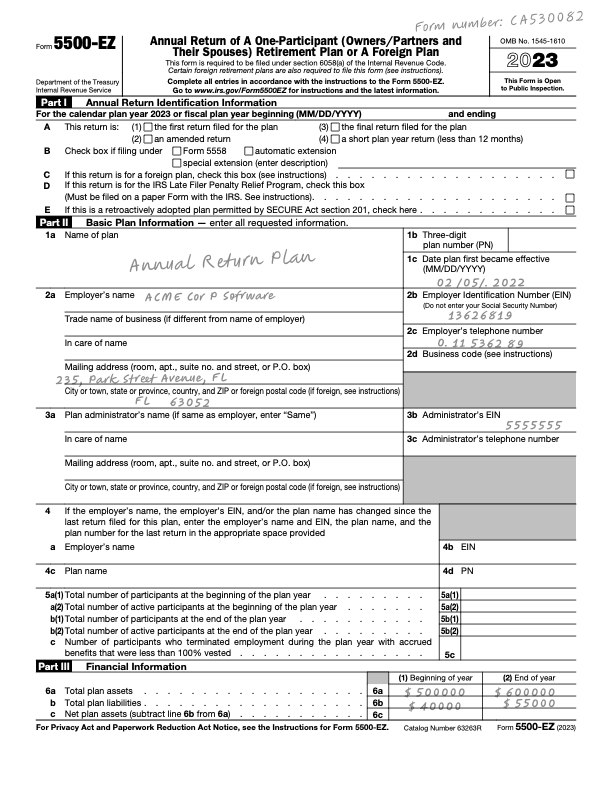

In [15]:
tslab.display.png(await getPage(formPdfPath, 0));


In [16]:
const formSchema = z
  .object({
    formNumber: z.string().describe("The Form Number"),
    startDate: z.string().describe("Effective Date"),
    beginningOfYear: z.string().describe("The plan liabilities beginning of the year"),
    endOfYear: z.string().describe("The plan liabilities end of the year"),
  })
  .describe(
    "Extract the form number, fiscal start date, fiscal end date, and the plan liabilities beginning of the year and end of the year."
  );

const formData = await extractStructuredDataFromPdf<typeof formSchema>(formPdfPath, formSchema);

console.log(`Extracted Form Number: ${formData.formNumber} with start date ${formData.startDate}.`);
console.log(
  `Plan liabilities beginning of the year ${formData.beginningOfYear} and end of the year ${formData.endOfYear}.`
);


File handwriting_form is ready. [ACTIVE]
Extracted Form Number: 5500-EZ with start date 02/05/2022.
Plan liabilities beginning of the year $40000 and end of the year $55000.


## Learning more

If you want to learn more about the File API, Structured Outputs and how to use it to process images, audio, and video files, check out the following resources:

- Learn more about the [File API](../quickstarts/File_API.ipynb) with the quickstart.
- Learn more about prompting with [media files](https://ai.google.dev/gemini-api/docs/file-prompting-strategies) in the docs, including the supported formats and maximum length.
- Learn more about [Structured Outputs](https://ai.google.dev/gemini-api/docs/file-prompting-strategies) in the docs.
